<a href="https://colab.research.google.com/github/Cxris2145/MineriaDatos2026/blob/main/ExportacionesChile2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Links**

https://www.kaggle.com/datasets/michallublin/chile-export-products-20172021

https://github.com/UXDynamicSolution/MineriaDatosDuocPAO/blob/main/eda_ejercicio.ipynb

#***Análisis de Exportaciones de Chile (2017 - 2021)***



Este proyecto realiza un análisis exploratorio del dataset **"ChileExport.csv"**, el cual documenta la actividad comercial de Chile con el exterior. El conjunto de datos permite segmentar la información bajo los siguientes criterios:



* **Ejes Geográficos:** Identificación de más de 220 países de destino.

* **Clasificación Sectorial:** División entre productos Mineros y No Mineros (Agropecuarios, Forestales, Servicios, etc.).



* **Métricas de Valor:** Registro de ingresos anuales en USD para evaluar el impacto económico de cada producto.



**Objetivo:** Procesar los datos nominales y cuantitativos para identificar tendencias comerciales y la composición de la matriz exportadora nacional en los últimos 5 años

#**Mapeo de tablas**

country: Categórico | Nominal | Son nombres de paises, no tienen orden

1_category:  Categórico | Nominal | Clasficación genreal, no tiene jerarquia numérica

2_category: Categórico | Nominal | Subcategoría, sigue siendo solo etiqueta

Product: Categórico | Nominal | Nombre del producto, no se puede ordenar

year: Numérico | Intervalo | Tiene orden y diferecias iguales, pero no cero absoluto

income_in_USD: Numérico | Ratio | Tiene cero real y permite proporcones

#**Descripción de las columnas del dataset**

Country: País al que se exporta el producto

1 category: Indica si la exportación es minera o no minera

2 category: Tipo de producto o sector (frutas, minería, alimentos, etc.)

Product: Producto específico exportado

Year: Año en que se realizó la exportación

Income in USD: Monto de dinero generado por la exportación en dólares


In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [64]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas
pd.set_option('display.max_rows', None)


In [65]:
df = pd.read_csv("ChileExport.csv", sep=';')
df.head()

,Country,1 category,2 category,Product,Year,Income in USD
0,China,Minero,Minería,Minerales de cobre y sus concentrados,2017,6470444174
1,China,Minero,Minería,Cobre,2017,7604230274
2,China,Minero,Minería,Minerales de hierro y sus concentrados,2017,"616711446,1"
3,China,Minero,Minería,Litio,2017,234218255
4,China,Minero,Minería,Minerales de molibdeno y sus concentrados,2017,"37490057,93"


In [66]:
#Limpieza de datos

df['Income in USD'] = pd.to_numeric(df['Income in USD'], errors='coerce')
df.columns = df.columns.str.strip()
df = df.drop_duplicates()

In [67]:
df_anio = df["Year"].describe()
print(df_anio)

count    21385.000000
mean      2019.000000
std          1.414247
min       2017.000000
25%       2018.000000
50%       2019.000000
75%       2020.000000
max       2021.000000
Name: Year, dtype: float64


In [68]:
# Cuenta en cuántas filas (registros de exportación) aparece cada país de destino.
# Chile tuvo más transacciones o diversidad de productos exportados entre 2017 y 2021.

df_country = df["Country"].value_counts()
print(df_country)

Country
Estados Unidos de América                              355
China                                                  350
Japón                                                  335
Perú                                                   335
Brasil                                                 330
Canadá                                                 330
España                                                 330
Alemania                                               315
Colombia                                               315
México                                                 310
Holanda                                                305
Corea del Sur                                          305
Italia                                                 300
Reino Unido                                            295
Argentina                                              295
Bélgica                                                280
Ecuador                                         

In [69]:
df_country = df["1 category"].value_counts()
print(df_country)

1 category
No minero      19505
Minero          1865
(en blanco)       15
Name: count, dtype: int64


In [70]:
df_country = df["2 category"].value_counts()
print(df_country)

2 category
Frutas y frutos                                     5440
Otros alimentos                                     3345
Productos del mar                                   2855
Forestales y sus derivados                          2150
Otros productos relevantes                          2040
Minería                                             1865
Vitivinícola                                        1815
Resto No minería                                    1060
Exportación de servicios calificados por Aduanas     800
(en blanco)                                           15
Name: count, dtype: int64


In [71]:
df_country = df["Product"].value_counts()
print(df_country)

Product
Resto No minería                                    1060
Vinos                                                840
Exportación de servicios calificados por Aduanas     800
Madera y sus manufacturas                            645
Resto Forestales y sus derivados                     620
Papel y cartón y sus manufacturas                    605
Uvas                                                 600
Conservas y preparaciones de pescados y mariscos     590
Resto Otros alimentos                                590
Vinos espumosos                                      580
Manzanas                                             500
Ciruelas                                             490
Salmones y truchas                                   470
Nueces de nogal                                      460
Medicamentos                                         445
Kiwis                                                410
Resto Frutas y frutos                                395
Mostos de uva          

In [72]:
df.tail()

# Aquí se muestran las últimas filas del dataset.
#Esta vista sirve para revisar cómo se ven los datos al final
# y detectar posibles valores extraños o errores.

,Country,1 category,2 category,Product,Year,Income in USD
21380,Gambia,No minero,Exportación de servicios calificados por Aduanas,Exportación de servicios calificados por Aduanas,2021,0.0
21381,Gambia,No minero,Resto No minería,Resto No minería,2021,0.0
21382,Groenlandia,No minero,Resto No minería,Resto No minería,2021,0.0
21383,República de Yemen,No minero,Resto No minería,Resto No minería,2021,0.0
21384,Timor Oriental,No minero,Resto No minería,Resto No minería,2021,0.0


In [73]:
df.shape

(21385, 6)

In [74]:
df.dtypes

,0
Country,object
1 category,object
2 category,object
Product,object
Year,int64
Income in USD,float64


In [75]:
df.isnull().sum()

,0
Country,0
1 category,0
2 category,0
Product,0
Year,0
Income in USD,13237


In [76]:
df.columns

Index(['Country', '1 category', '2 category', 'Product', 'Year',
       'Income in USD'],
      dtype='object')

In [77]:
# Revisamos si hay filas duplicadas en el dataset (datos repetidos)
df.duplicated().sum()

# Eliminamos duplicados si existen
df = df.drop_duplicates()

In [78]:
# Limpiamos los nombres de columnas por si tienen espacios raros
df.columns = df.columns.str.strip()

In [79]:
# Contamos cuántas exportaciones son mineras vs no mineras
df['1 category'].value_counts()

,count
1 category,
No minero,19505
Minero,1865
(en blanco),15


In [80]:
# Esta función sirve para poner los valores encima de cada barra del gráfico
def agregar_valores(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom')

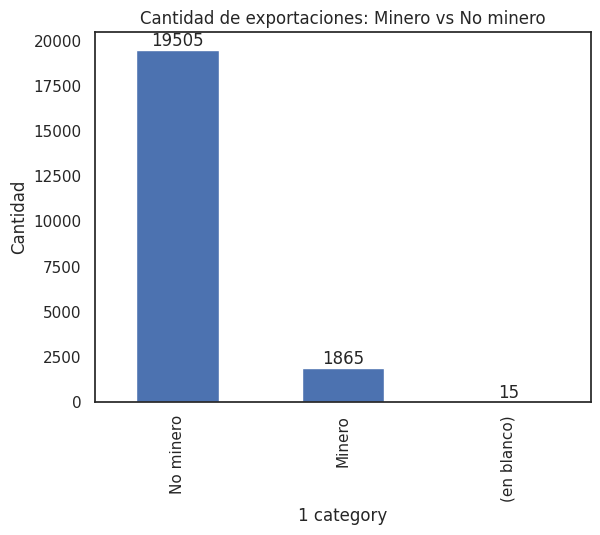

In [99]:
ax = df['1 category'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Cantidad de exportaciones: Minero vs No minero")
plt.ylabel("Cantidad")

agregar_valores(ax)

plt.show()

# Este gráfico muestra cuántas exportaciones pertenecen al sector minero y cuántas al resto de sectores.
# Sirve para entender qué tipo de exportación aparece más en los datos.
# Por ejemplo, si hay muchas más exportaciones no mineras, significa que hay más variedad de productos fuera de la minería,
# aunque eso no necesariamente significa que generen más dinero.

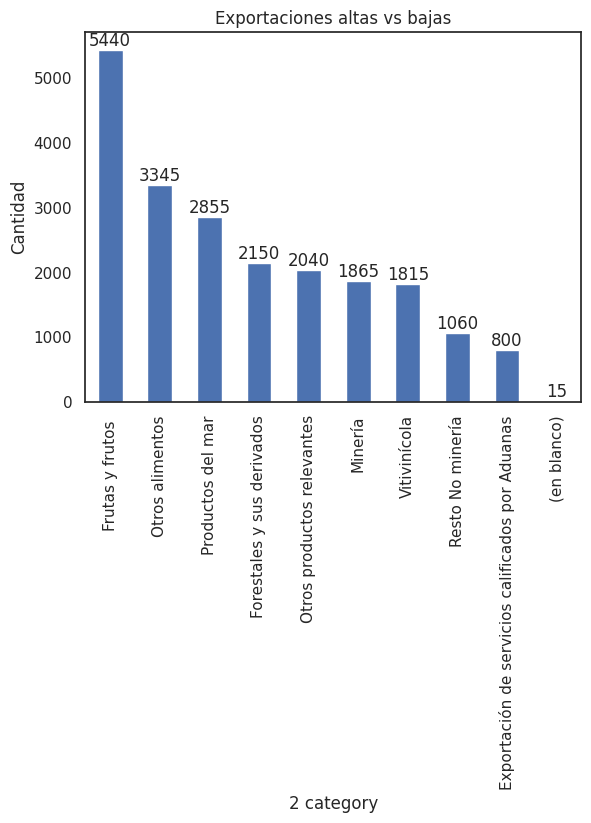

In [100]:
ax = df['2 category'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Exportaciones altas vs bajas")
plt.ylabel("Cantidad")

agregar_valores(ax)

plt.show()

# Este gráfico muestra cuántas exportaciones hay en cada tipo de producto o sector.
# Cada barra representa un tipo de exportación (por ejemplo frutas, alimentos, minería, etc.)
# y el número arriba indica cuántas veces aparece en los datos.
#
# Sirve para entender qué tipo de productos se exportan más en cantidad.
# Por ejemplo, se puede ver que las frutas y frutos aparecen mucho más que otros sectores,
# lo que indica que son muy frecuentes en las exportaciones.
#
# También se observa que algunos sectores aparecen muy poco, lo que significa
# que tienen menos participación en cantidad dentro del dataset.
#
# Este gráfico ayuda a ver qué se exporta más seguido,
# pero no necesariamente cuánto dinero genera cada tipo.

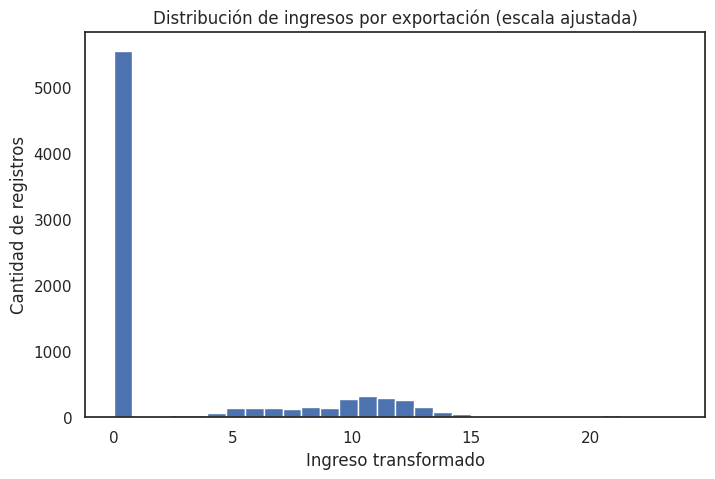

In [101]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['Income in USD']), bins=30)

plt.title("Distribución de ingresos por exportación (escala ajustada)")
plt.xlabel("Ingreso transformado")
plt.ylabel("Cantidad de registros")
plt.show()

# Este gráfico muestra cómo se distribuyen los montos de dinero de las exportaciones.
# Sirve para ver si la mayoría de las exportaciones tiene valores bajos o si hay muchas con valores altos.
# Generalmente, se observa que hay muchas exportaciones pequeñas y pocas que generan mucho dinero.

In [84]:
# Este comando sirve para resumir los montos de exportación en una sola vista.
# Nos muestra el valor promedio, el más bajo, el más alto y otros datos que ayudan
# a entender cómo son los ingresos en general.
df['Income in USD'].describe()

,Income in USD
count,8.148000e+03
mean,2.449763e+07
std,3.892551e+08
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.150000e+03
max,1.876542e+10


In [85]:
# Aquí sumamos todo el dinero exportado en cada año.
# Esto sirve para comparar si hubo años donde Chile exportó más o menos.
exportaciones_por_anio = df.groupby('Year')['Income in USD'].sum()
print(exportaciones_por_anio)

Year
2017    3.046204e+10
2018    3.784571e+10
2019    3.646482e+10
2020    3.908695e+10
2021    5.574718e+10
Name: Income in USD, dtype: float64


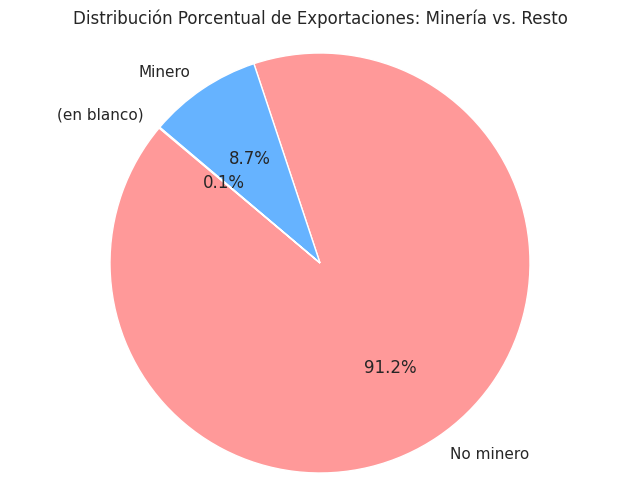

In [102]:
# 1. Preparamos los datos contando las frecuencias de la categoría principal
data_torta = df['1 category'].value_counts()

# 2. Creamos el gráfico
plt.figure(figsize=(8, 6))
plt.pie(data_torta,
        labels = data_torta.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99'])

plt.title("Distribución Porcentual de Exportaciones: Minería vs. Resto")
plt.axis('equal')  # Para que el gráfico sea un círculo perfecto

plt.show()

# Este gráfico compara dos cosas al mismo tiempo: si la exportación es minera o no,
# y el tipo de producto o sector al que pertenece.
#
# Cada grupo muestra cuántas exportaciones hay de cada tipo dentro de minería y no minería.
# Esto permite ver cómo se distribuyen los distintos productos según el tipo de exportación.
#
# Es importante notar la precensia de una pequeña proporción de registros clasificados como "(EN BLANCO)"
# Esto representa datos que no traían una etiqueta dde sector definida en el dataset original; al ser un valor minimo
# no altera las tendencias generales del análisis.
#
# Por ejemplo, se puede observar que en las exportaciones no mineras hay mucha mayor variedad
# y cantidad de productos, como frutas, alimentos o productos del mar.
#
# En cambio, las exportaciones mineras son menos variadas y se concentran en menos categorías.
#
# Este gráfico ayuda a entender cómo se reparten los distintos tipos de productos
# entre la minería y el resto de las exportaciones.

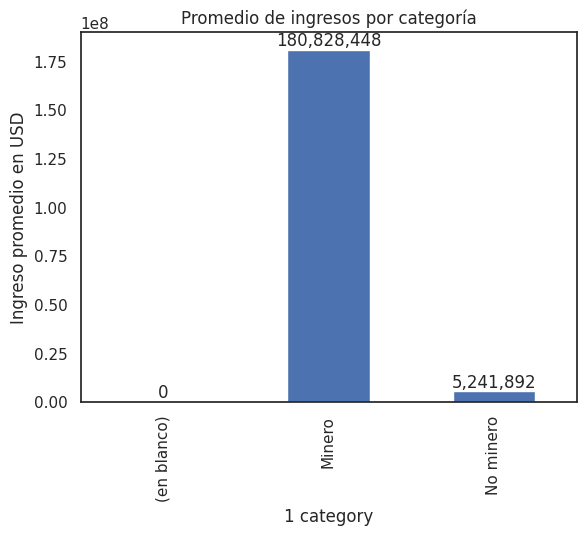

In [103]:
ax = df.groupby('1 category')['Income in USD'].mean().plot(kind='bar')

plt.title("Promedio de ingresos por categoría")
plt.ylabel("Ingreso promedio en USD")

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

# Este gráfico muestra el dinero promedio que genera cada tipo de exportación.
# Es decir, no cuenta cuántas exportaciones hay, sino cuánto dinero deja cada una en promedio.
#
# Se puede ver que la minería tiene un promedio mucho más alto que las exportaciones no mineras,
# lo que significa que aunque haya menos exportaciones mineras, estas generan mucho más dinero.
#
# En cambio, las exportaciones no mineras tienen un promedio mucho menor,
# lo que indica que son más en cantidad, pero generan menos dinero por cada una.
#
# Este gráfico muestra que la minería domina en dinero,
# aunque no necesariamente en cantidad de exportaciones.

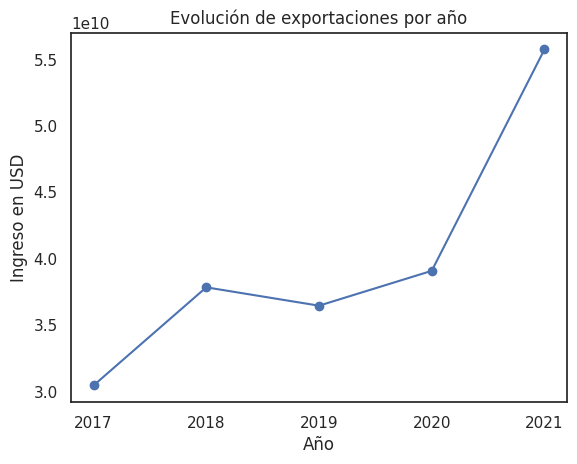

In [104]:
exportaciones_anio = df.groupby('Year')['Income in USD'].sum()

ax = exportaciones_anio.plot(marker='o')

plt.title("Evolución de exportaciones por año")
plt.xlabel("Año")
plt.ylabel("Ingreso en USD")

# Forzar que el eje X muestre solo años enteros
plt.xticks(exportaciones_anio.index)

plt.show()

# Este gráfico muestra cómo han cambiado los ingresos de exportación a lo largo de los años.
# Cada punto representa el total de dinero exportado en un año específico.
#
# Se puede observar que las exportaciones en general han ido aumentando con el tiempo,
# aunque hay pequeñas variaciones entre algunos años.
#
# Por ejemplo, hay un crecimiento desde 2017 a 2018, luego una leve baja en 2019,
# y después vuelve a subir hasta alcanzar su punto más alto en 2021.
#
# Este gráfico permite ver que las exportaciones han crecido en el tiempo,
# mostrando una tendencia general al alza.

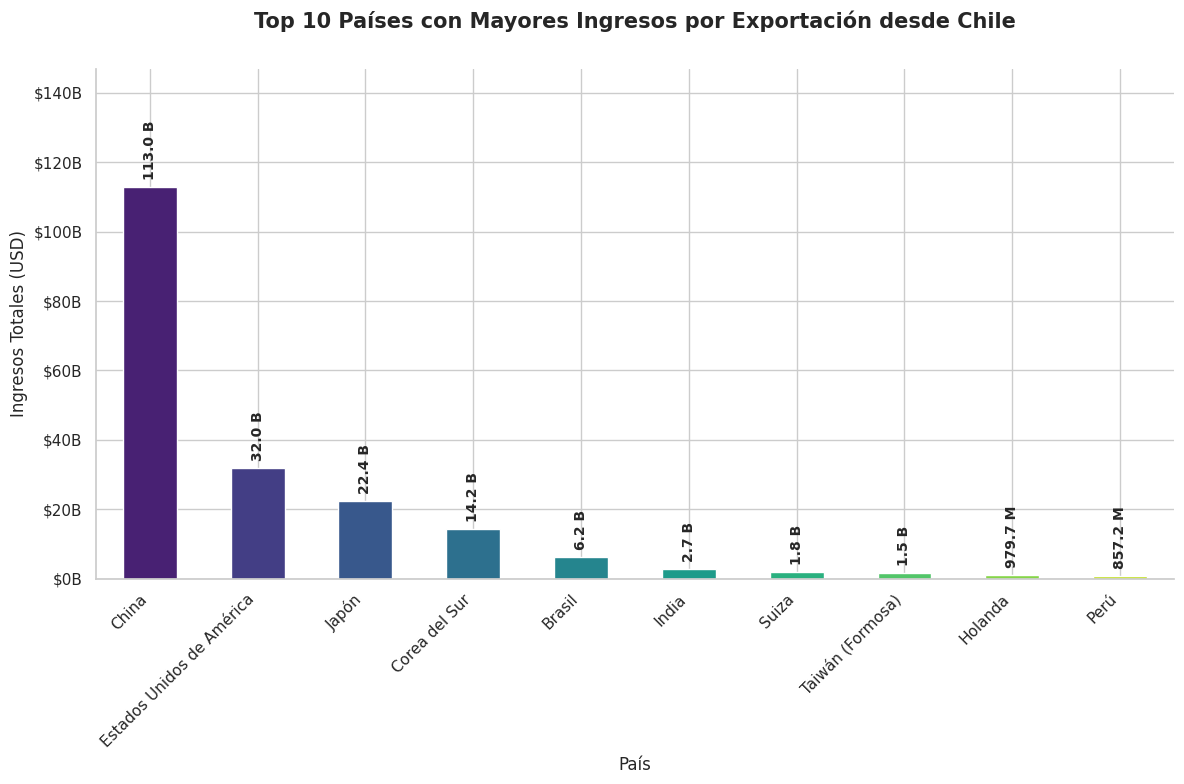

In [105]:
import matplotlib.ticker as ticker

# Agrupamos y obtenemos los 10 principales (orden descendente para barra vertical)
top_paises = df.groupby('Country')['Income in USD'].sum().sort_values(ascending=False).head(10)

# Configuración de estilo y tamaño (más alto para dar espacio a las etiquetas)
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Gráfico de barras verticales
colors = sns.color_palette("viridis", n_colors=10)
ax = top_paises.plot(kind='bar', color=colors)

# Títulos y etiquetas
plt.title("Top 10 Países con Mayores Ingresos por Exportación desde Chile", fontsize=15, pad=30, fontweight='bold')
plt.ylabel("Ingresos Totales (USD)", fontsize=12)
plt.xlabel("País", fontsize=12)

# Rotar nombres de países para que no choquen
plt.xticks(rotation=45, ha='right')

# Formateador para el eje Y (Billones)
def format_billions(x, pos):
    return f'${x/1e9:,.0f}B'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# Añadimos las etiquetas de datos sobre las barras con rotación
for p in ax.patches:
    height = p.get_height()
    if height >= 1e9:
        label = f'{height/1e9:,.1f} B'
    else:
        label = f'{height/1e6:,.1f} M'

    # Ajustamos la posición y rotamos 90 grados para que quepan verticalmente
    ax.annotate(label,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', rotation=90,
                xytext=(0, 5), textcoords='offset points')

# Ajustar márgenes para que no se corte la parte superior
plt.ylim(0, top_paises.max() * 1.3)

sns.despine()
plt.tight_layout()
plt.show()



# Este gráfico muestra los 10 países que más ingresos generan por exportaciones desde Chile.
# Cada barra representa el total de dinero que se exporta a cada país.
#
# Se puede observar que China es, por mucho, el país que más ingresos aporta a las exportaciones chilenas,
# seguido de Estados Unidos y Japón.
#
# También se agregaron etiquetas en millones (M) y billones (B) para facilitar la lectura,
# lo que permite entender rápidamente la magnitud del dinero sin tener que interpretar números muy grandes.
#
# Este gráfico destaca la importancia de ciertos mercados para las exportaciones de Chile.

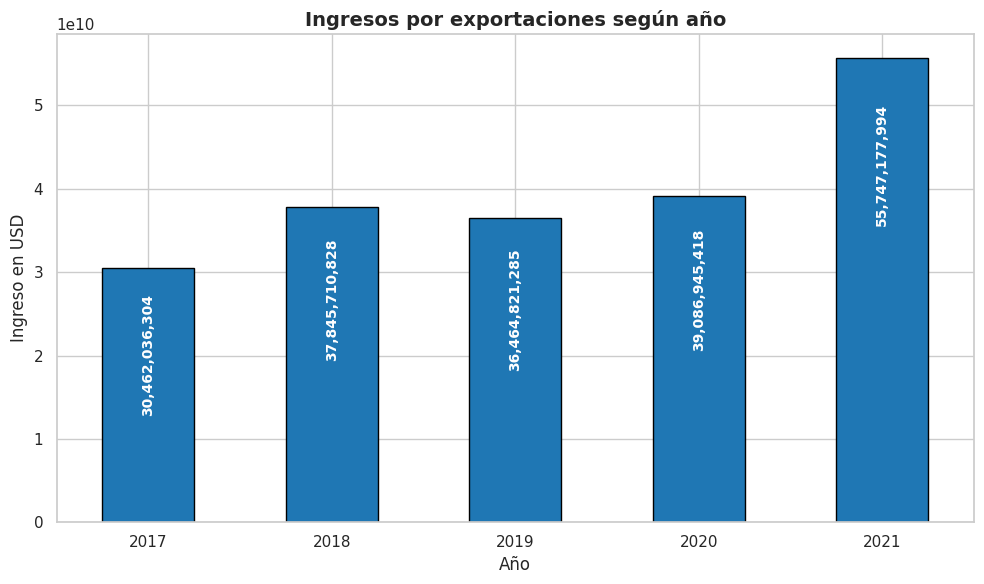

In [106]:
# Aseguramos limpieza de datos
if df['Income in USD'].dtype == 'object':
    df['Income in USD'] = df['Income in USD'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df['Income in USD'] = pd.to_numeric(df['Income in USD'], errors='coerce')

# Agrupación
exportaciones_por_anio = df.groupby('Year')['Income in USD'].sum()

# Configuración del estilo
plt.figure(figsize=(10, 6))
ax = exportaciones_por_anio.plot(kind='bar', color='#1f77b4', edgecolor='black')

plt.title("Ingresos por exportaciones según año", fontsize=14, fontweight='bold')
plt.xlabel("Año", fontsize=12)
plt.ylabel("Ingreso en USD", fontsize=12)
plt.xticks(rotation=0)

# Agregar valores dentro de los rectángulos
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:,.0f}',
                    (p.get_x() + p.get_width() / 2, height * 0.9),
                    ha='center',
                    va='top',
                    rotation=90,
                    color='white',
                    fontweight='bold',
                    fontsize=10)

plt.tight_layout()
plt.show()

# Este gráfico muestra cuánto dinero se exportó en cada año.
# Cada barra representa el total de ingresos por exportaciones en ese año.
#
# Se puede observar que los ingresos van aumentando en general con el tiempo,
# aunque hay una pequeña baja en 2019 en comparación con 2018.
#
# Después de eso, las exportaciones vuelven a subir en 2020
# y alcanzan su valor más alto en 2021.
#
# Este gráfico permite ver qué años fueron mejores en exportaciones
# y muestra una tendencia general de crecimiento.

In [91]:
# Este análisis sirve para descubrir qué productos son los que más dinero aportan.
# Ayuda a entender cuáles son los productos más importantes dentro de las exportaciones.
top_productos = df.groupby('Product')['Income in USD'].sum().sort_values(ascending=False).head(10)
print(top_productos)

Product
Minerales de cobre y sus concentrados     8.207595e+10
Cobre                                     7.261270e+10
Salmones y truchas                        1.431753e+10
Celulosa                                  8.287415e+09
Cerezas                                   5.377386e+09
Minerales de hierro y sus concentrados    4.022995e+09
Resto No minería                          3.303853e+09
Madera y sus manufacturas                 3.138171e+09
Oro                                       1.789225e+09
Vinos                                     6.258668e+08
Name: Income in USD, dtype: float64


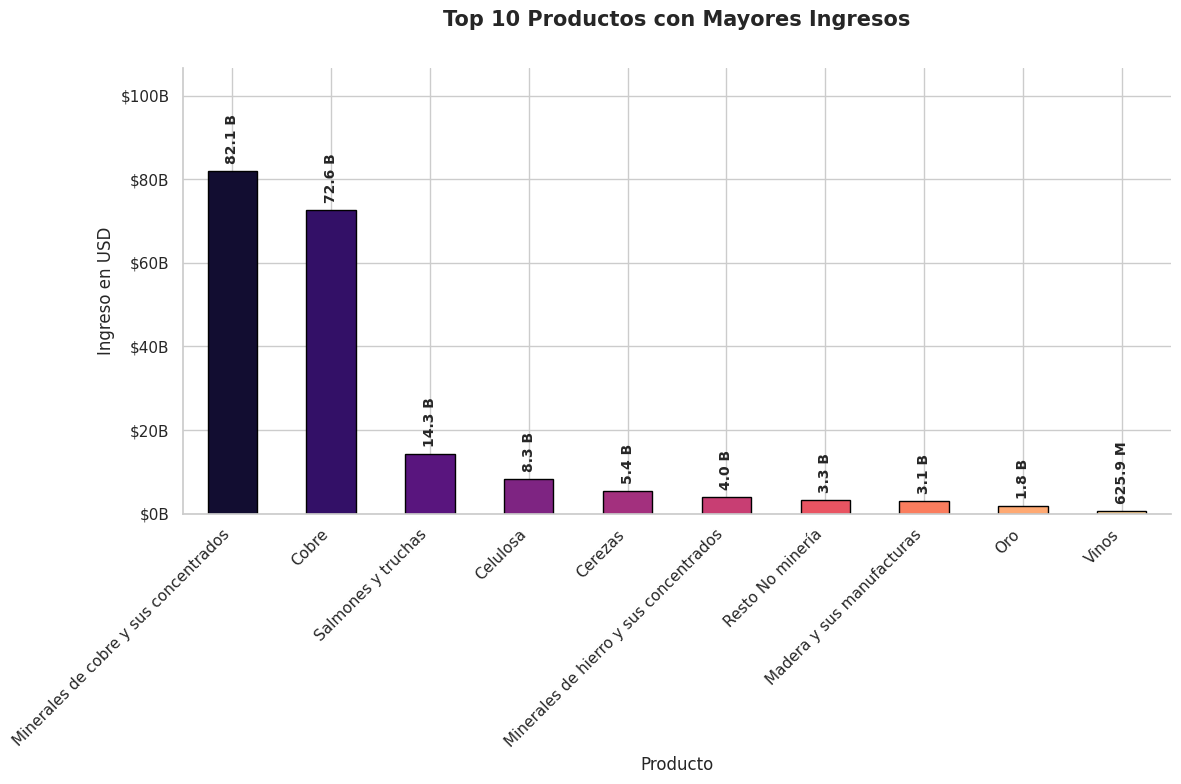

In [107]:
import matplotlib.ticker as ticker

# Agrupamos los datos
top_productos = df.groupby('Product')['Income in USD'].sum().sort_values(ascending=False).head(10)

# Configuración de estilo y tamaño
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Gráfico de barras verticales (hacia arriba)
colors = sns.color_palette("magma", n_colors=10)
ax = top_productos.plot(kind='bar', color=colors, edgecolor='black')

# Títulos y etiquetas
plt.title("Top 10 Productos con Mayores Ingresos", fontsize=15, pad=30, fontweight='bold')
plt.ylabel("Ingreso en USD", fontsize=12)
plt.xlabel("Producto", fontsize=12)

# Rotar nombres de productos para legibilidad
plt.xticks(rotation=45, ha='right')

# Formateador para el eje Y (Billones)
def format_billions(x, pos):
    return f'${x/1e9:,.0f}B'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# Añadimos etiquetas de datos con formato simplificado
for p in ax.patches:
    height = p.get_height()
    if height >= 1e9:
        label = f'{height/1e9:,.1f} B'
    else:
        label = f'{height/1e6:,.1f} M'

    ax.annotate(label,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', rotation=90,
                xytext=(0, 5), textcoords='offset points')

plt.ylim(0, top_productos.max() * 1.3)
sns.despine()
plt.tight_layout()
plt.show()

# Este gráfico muestra los 10 productos que generan más dinero en las exportaciones.
# Cada barra representa el ingreso total que aporta un producto específico.
#
# Se puede observar claramente que los productos relacionados con la minería,
# especialmente los minerales de cobre y el cobre en general, son los que generan
# la mayor cantidad de ingresos, muy por encima del resto.
#
# Luego aparecen otros productos como salmones, celulosa o cerezas,
# pero con montos bastante menores en comparación con los principales.
#
# También se agregaron etiquetas en millones (M) y billones (B) para facilitar la lectura,
# lo que permite entender rápidamente la magnitud del dinero sin tener que interpretar números muy grandes.
#
# Este gráfico muestra que la minería domina ampliamente las exportaciones en términos de dinero,
# mientras que otros productos, aunque importantes, tienen un impacto mucho menor.

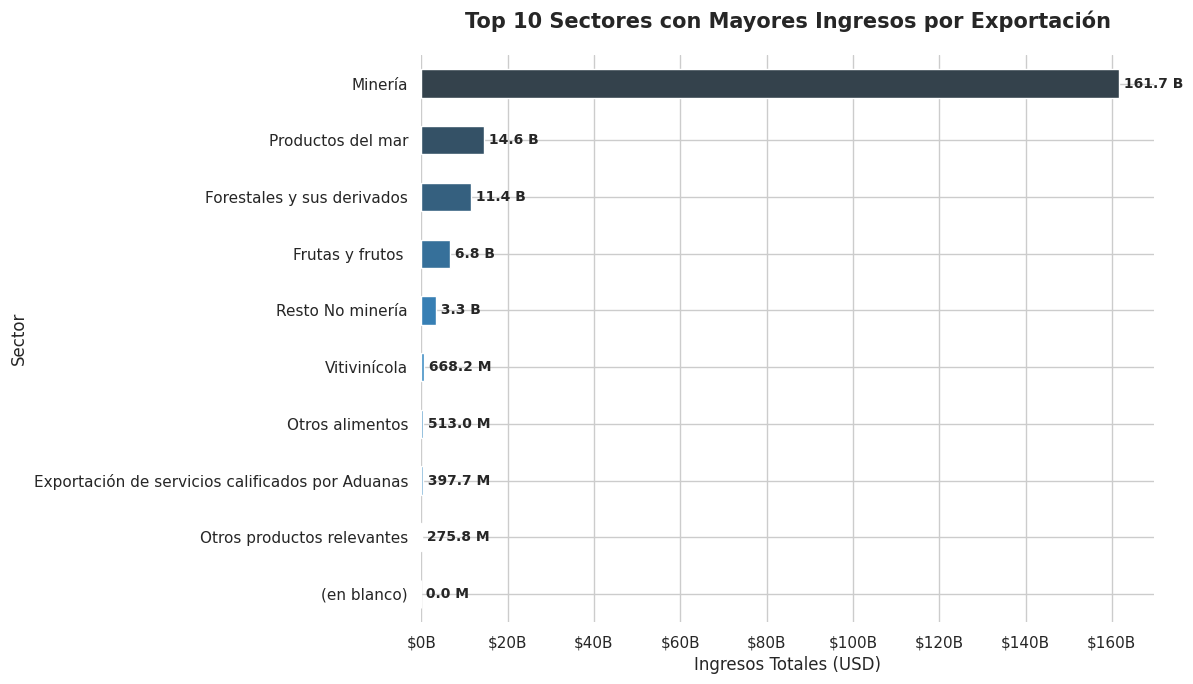

In [108]:
import matplotlib.ticker as ticker

# Mejorando el diseño del gráfico de sectores por ingresos
ingresos_segunda_categoria = df.groupby('2 category')['Income in USD'].sum().sort_values(ascending=True).tail(10)

# Configuramos un estilo más limpio
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# Usamos barras horizontales para que los nombres se lean mejor
colors = sns.color_palette("Blues_d", n_colors=10)
ax = ingresos_segunda_categoria.plot(kind='barh', color=colors)

# Títulos y etiquetas con mejor formato
plt.title("Top 10 Sectores con Mayores Ingresos por Exportación", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Ingresos Totales (USD)", fontsize=12)
plt.ylabel("Sector", fontsize=12)

# Formateamos el eje X para que muestre billones con el signo $
def format_billions(x, pos):
    return f'${x/1e9:,.0f}B'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# Añadimos etiquetas de datos formateadas al final de cada barra
for p in ax.patches:
    width = p.get_width()
    if width >= 1e9:
        label = f' {width/1e9:,.1f} B'
    else:
        label = f' {width/1e6:,.1f} M'

    ax.annotate(label,
                (width, p.get_y() + p.get_height() / 2),
                va='center', fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Este gráfico muestra los sectores o tipos de productos que generan más dinero en las exportaciones.
# Cada barra representa el ingreso total de un sector, ordenado de menor a mayor para facilitar la comparación.
#
# Se puede observar claramente que la minería es, por lejos, el sector que más dinero aporta,
# superando ampliamente a todos los demás.
#
# Luego aparecen sectores como productos del mar, forestales y frutas,
# que también generan ingresos importantes, pero mucho menores en comparación con la minería.
#
# Los demás sectores, como vitivinícola, alimentos u otros productos,
# tienen una participación bastante más baja en términos de dinero.
#
# Además, los valores están mostrados en millones (M) y billones (B),
# lo que ayuda a entender mejor la magnitud de los ingresos sin ver números tan grandes.
#
# Este gráfico deja claro que la minería domina las exportaciones en dinero,
# mientras que los otros sectores aportan, pero en menor escala.

In [94]:
# Aquí calculamos qué parte del dinero total corresponde a cada categoría.
# Esto ayuda a entender qué sector tiene más peso dentro de todas las exportaciones.
porcentaje_categoria = (df.groupby('1 category')['Income in USD'].sum() / df['Income in USD'].sum()) * 100
print(porcentaje_categoria)

1 category
(en blanco)     0.000000
Minero         80.989585
No minero      19.010415
Name: Income in USD, dtype: float64


In [95]:
# Aquí creamos un ranking de países según cuánto dinero generan.
# Sirve para ordenar claramente quién está primero, segundo, etc.

ranking_paises = df.groupby('Country')['Income in USD'].sum().rank(ascending=False)

ranking_paises.sort_values().head(10)

,Income in USD
Country,
China,1.0
Estados Unidos de América,2.0
Japón,3.0
Corea del Sur,4.0
Brasil,5.0
India,6.0
Suiza,7.0
Taiwán (Formosa),8.0
Holanda,9.0


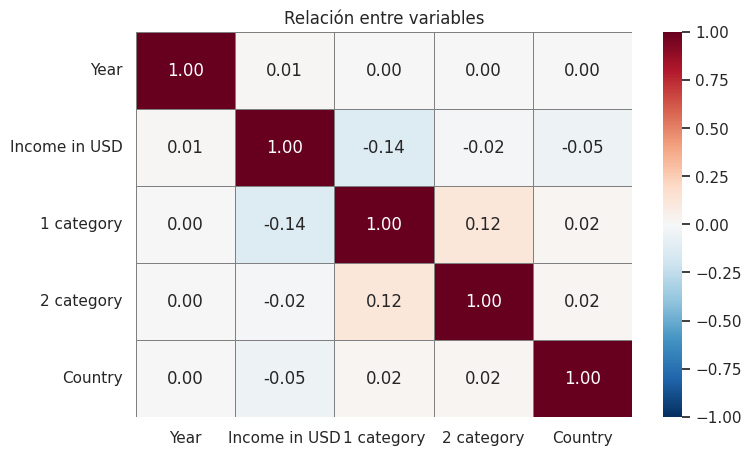

In [115]:
df_heatmap = df.copy()

df_heatmap['1 category'] = df_heatmap['1 category'].astype('category').cat.codes
df_heatmap['2 category'] = df_heatmap['2 category'].astype('category').cat.codes
df_heatmap['Country'] = df_heatmap['Country'].astype('category').cat.codes

corr = df_heatmap[['Year', 'Income in USD', '1 category', '2 category', 'Country']].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Relación entre variables")
plt.show()

# Este gráfico muestra la relación entre distintas variables del dataset,
# como el año, el ingreso, las categorías y el país.
#
# Los valores van desde -1 a 1:
# - Cercano a 1 significa que hay una relación fuerte (se mueven juntas)
# - Cercano a 0 significa que casi no hay relación
# - Cercano a -1 indica una relación inversa
#
# En este caso, se puede observar que la mayoría de los valores están cerca de 0,
# lo que indica que no hay una relación fuerte entre las variables.
#
# Por ejemplo, el año casi no tiene relación con el ingreso,
# lo que significa que el dinero exportado no depende directamente del año.
#
# También se ve que las categorías tienen una relación muy baja con el ingreso,
# por lo que no explican completamente cuánto dinero se genera.

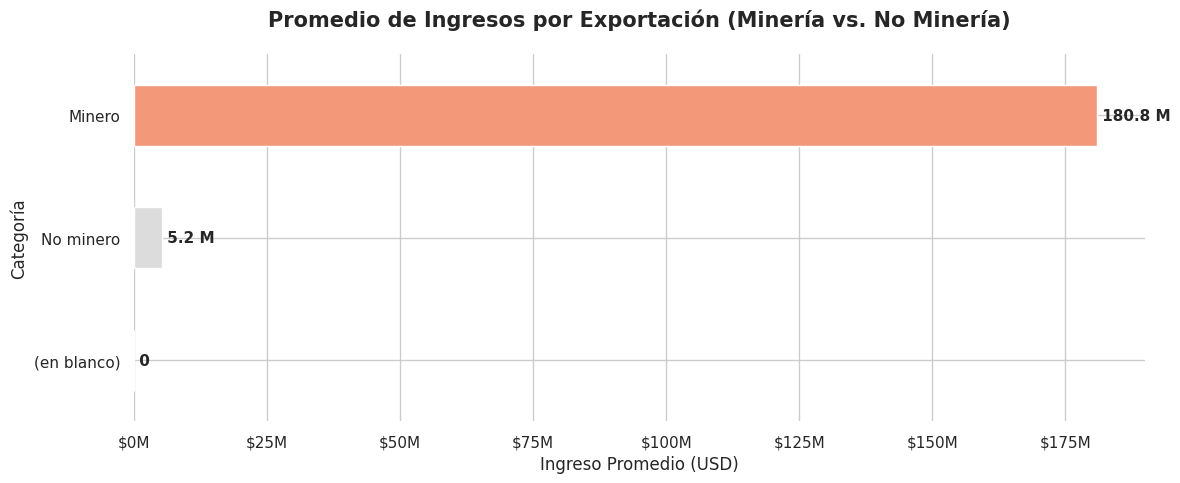

In [110]:
import matplotlib.ticker as ticker

# Agrupamos y calculamos el promedio
promedio_categoria = df.groupby('1 category')['Income in USD'].mean().sort_values(ascending=True)

# Configuración de estilo y tamaño
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))

# Gráfico de barras horizontales
colors = sns.color_palette("coolwarm", n_colors=len(promedio_categoria))
ax = promedio_categoria.plot(kind='barh', color=colors)

# Títulos y etiquetas
plt.title("Promedio de Ingresos por Exportación (Minería vs. No Minería)", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Ingreso Promedio (USD)", fontsize=12)
plt.ylabel("Categoría", fontsize=12)

# Formateador para el eje X (Millones)
def format_millions(x, pos):
    return f'${x/1e6:,.0f}M'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_millions))

# Añadimos etiquetas de datos formateadas
for p in ax.patches:
    width = p.get_width()
    if width >= 1e6:
        label = f' {width/1e6:,.1f} M'
    else:
        label = f' {width:,.0f}'

    ax.annotate(label,
                (width, p.get_y() + p.get_height() / 2),
                va='center', fontsize=11, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Este gráfico muestra el dinero promedio que genera cada exportación según su tipo.
# Se observa que, aunque las exportaciones mineras son menos frecuentes,
# cada una genera muchísimo más dinero en promedio que una exportación no minera.
# Esto confirma que la minería es la actividad de mayor valor unitario para Chile.

#**CONCLUSIÓN GENERAL**

 A partir del análisis realizado sobre las exportaciones de Chile, se pueden destacar los siguientes puntos:

- La minería es el sector que más dinero genera en las exportaciones.
Aunque no siempre es el que tiene más cantidad de registros, sí es el que aporta mayor valor económico.

 - Las exportaciones no mineras son más variadas y aparecen en mayor cantidad,
   pero en promedio generan menos dinero por cada exportación.

 - China es el principal país al que Chile exporta, con una diferencia muy grande
   en comparación con otros países como Estados Unidos o Japón.
   Esto indica una fuerte dependencia de ese mercado.

 - Los productos relacionados con el cobre son los que más ingresos generan,
   lo que refuerza la importancia de la minería dentro de la economía.

 - A lo largo de los años, las exportaciones han mostrado una tendencia general al alza,
   aunque con algunas pequeñas variaciones entre ciertos años.

 - No se observa una relación directa fuerte entre el año y el ingreso,
   lo que significa que los montos pueden variar bastante dentro de cada periodo.

 - Existen muchas exportaciones con valores bajos y pocas con valores muy altos,
   lo que indica una distribución desigual del dinero.

 En simple, este análisis permite entender qué se exporta, cuánto dinero se genera,
 qué sectores son más importantes y hacia dónde se dirigen las exportaciones de Chile.